In [1]:
import numpy as np
import matplotlib.pyplot as plt
import csv
import pandas as pd
from pathlib import Path
from tkinter import filedialog
import seaborn as sns
import itertools
from colour import Color
from datetime import date
import tifffile
import scipy  as spy
from skimage import filters

In [2]:
today = date.today()
print("Today's date:", today)
date_today = str(today)
date_today

Today's date: 2022-05-23


'2022-05-23'

In [246]:
askdirectory = filedialog.askdirectory() # show an "Open" dialog box and return the path to the folder on ONE date you want to process
path = Path(askdirectory)
path

WindowsPath('C:/Users/sofia/OneDrive/Documentos/2022_1winter/2022-05-19_flowin_phalloidin_newtaxol/CH4_DCX2nM_TypeWT_tax0.1uM')

In [247]:
folders = [x for x in path.iterdir() if x.is_dir()]
folders = [i for i in folders if str(i).rfind('Kymo') != -1]
folders

[WindowsPath('C:/Users/sofia/OneDrive/Documentos/2022_1winter/2022-05-19_flowin_phalloidin_newtaxol/CH4_DCX2nM_TypeWT_tax0.1uM/Kymographs-1-Stream_Composite_GFP'),
 WindowsPath('C:/Users/sofia/OneDrive/Documentos/2022_1winter/2022-05-19_flowin_phalloidin_newtaxol/CH4_DCX2nM_TypeWT_tax0.1uM/Kymographs-1-Stream_Composite_RFP')]

In [248]:
files = []

for i in folders:
    if str(i).rfind('GFP') != -1 :
        GFP_files = [x for x in i.iterdir() if x.is_file()]
        
    if str(i).rfind('RFP') != -1 :
        RFP_files = [x for x in i.iterdir() if x.is_file()]

GFP_files

[WindowsPath('C:/Users/sofia/OneDrive/Documentos/2022_1winter/2022-05-19_flowin_phalloidin_newtaxol/CH4_DCX2nM_TypeWT_tax0.1uM/Kymographs-1-Stream_Composite_GFP/Kymograph_001_0001-0403-0181.tif'),
 WindowsPath('C:/Users/sofia/OneDrive/Documentos/2022_1winter/2022-05-19_flowin_phalloidin_newtaxol/CH4_DCX2nM_TypeWT_tax0.1uM/Kymographs-1-Stream_Composite_GFP/Kymograph_002_0001-0097-0273.tif'),
 WindowsPath('C:/Users/sofia/OneDrive/Documentos/2022_1winter/2022-05-19_flowin_phalloidin_newtaxol/CH4_DCX2nM_TypeWT_tax0.1uM/Kymographs-1-Stream_Composite_GFP/Kymograph_003_0001-0161-0185.tif'),
 WindowsPath('C:/Users/sofia/OneDrive/Documentos/2022_1winter/2022-05-19_flowin_phalloidin_newtaxol/CH4_DCX2nM_TypeWT_tax0.1uM/Kymographs-1-Stream_Composite_GFP/Kymograph_004_0051-0537-0194.tif'),
 WindowsPath('C:/Users/sofia/OneDrive/Documentos/2022_1winter/2022-05-19_flowin_phalloidin_newtaxol/CH4_DCX2nM_TypeWT_tax0.1uM/Kymographs-1-Stream_Composite_GFP/Kymograph_005_0051-0522-0380.tif'),
 WindowsPath('C

## Get Metadata ##

In [293]:
DCXconc = '[DCX] ' r'$(n M)$'

Type = 'DCX Type'

taxol = '[Taxol] ' r'$(\mu M)$'
taxolnM = '[Taxol] ' r'$(n M)$'

In [250]:
i = path

dateloc = str(i).rfind("202")

CHloc = str(i).find("CH")
CHlocend = str(i).find('_', CHloc)

taxloc = str(i).rfind('tax')
taxlocend = str(i).find('uM', taxloc)

DCXloc = str(i).rfind('DCX')
DCXlocend = str(i).find('nM', DCXloc)

dcxtypeloc = str(i).find("Type")
dcxtypelocend = str(i).find('_', dcxtypeloc)

date = str(path)[dateloc : dateloc+10]
ch = str(i)[CHloc+2:CHlocend]
conc_tax = str(i)[taxloc+3:taxlocend]
conc_DCX = str(i)[DCXloc+3:DCXlocend]
DCX_type = str(i)[dcxtypeloc+4:dcxtypelocend]

conc_tax = float(conc_tax)
conc_DCX = float(conc_DCX)

date,ch, conc_tax, conc_DCX, DCX_type

('2022-05-19', '4', 0.1, 2.0, 'WT')

## Open kymograph ##

In [251]:
kymoR = tifffile.imread(RFP_files[0])
kymoG = tifffile.imread(GFP_files[0])

In [252]:
len(RFP_files)

10

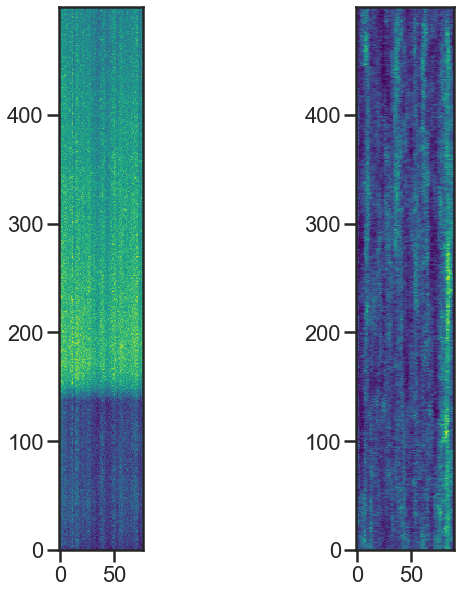

In [253]:
fig, ax = plt.subplots(1,2,figsize=(10,10))

ax[0].imshow(kymoR, interpolation='none', origin=[0, 0], cmap='viridis')
ax[1].imshow(kymoG, interpolation='none', origin=[0, 0], cmap='viridis')

In [254]:
def kymo_mean(files,roll):
    
    mean_kymo = []
    
    for i in files:
        kymo = tifffile.imread(i)
        mean_kymo = mean_kymo + [np.mean(kymo, axis=1)]
        
    mean_all_kymo = np.mean(mean_kymo, axis=0)
    
    result = pd.DataFrame({'Time (s)': np.arange(len(mean_all_kymo))/10, 'Intensity': mean_all_kymo})
    
    array = result['Intensity'].values
    result['Normal Intensity'] =  (array - min(array)) / (max(array) - min(array))
    
    result['Rolling Intensity'] =  result['Intensity'].rolling(roll, min_periods=1, center=True).mean()
    result['Rolling Intensity std'] =  result['Intensity'].rolling(roll, min_periods=1, center=True).std()
    
    array = result['Rolling Intensity'].values
    result['Normal Rolling Intensity'] =  (array - min(array)) / (max(array) - min(array))
    result['Normal Rolling Intensity std'] = result['Rolling Intensity std']/(max(array) - min(array))
    
        
    return result

In [255]:
roll =  10
allRFP= kymo_mean(RFP_files,roll)
allRFP['Channel'] = 'RFP'
allRFP['n'] = len(RFP_files)

allGFP= kymo_mean(GFP_files,roll)
allGFP['Channel'] = 'GFP'
allGFP['n'] = len(GFP_files)

data = pd.concat([allRFP, allGFP], ignore_index=True)
data['Date'] = date
data['CH'] = ch
data[taxol] = conc_tax
data[DCXconc] = conc_DCX
data[Type] = DCX_type 

In [256]:
def get_values(data):
    x = data['Time (s)'].values
    mean = data['Normal Rolling Intensity'].values
    std = data['Normal Rolling Intensity std'].values
    return x, mean, std

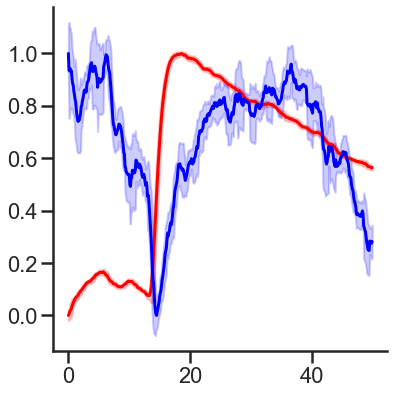

In [257]:
plt.figure(figsize=(6, 6))

x, mean, std = get_values(allRFP)
plt.plot(x, mean, 'r-')
plt.fill_between(x, mean - std, mean + std, color='r', alpha=0.2)

x, mean, std = get_values(allGFP)
plt.plot(x, mean, 'b-')
plt.fill_between(x, mean - std, mean + std, color='b', alpha=0.2)


sns.set_style("ticks")
sns.despine()
sns.set_context("poster", font_scale=1, rc={"lines.linewidth":3.0})

plt.tight_layout()

## Save data ##

In [258]:
data

,Time (s),Intensity,Normal Intensity,Rolling Intensity,Rolling Intensity std,Normal Rolling Intensity,Normal Rolling Intensity std,Channel,n,Date,CH,[Taxol] $(\mu M)$,[DCX] $(n M)$,DCX Type
0,0.0,753.073634,0.000000,757.329984,3.813510,0.000000,0.020781,RFP,10,2022-05-19,4,0.1,2.0,WT
1,0.1,754.383609,0.006876,758.136316,3.941486,0.004394,0.021479,RFP,10,2022-05-19,4,0.1,2.0,WT
2,0.2,756.667527,0.018864,759.688821,5.460586,0.012854,0.029757,RFP,10,2022-05-19,4,0.1,2.0,WT
3,0.3,761.215708,0.042736,760.617784,5.697549,0.017917,0.031048,RFP,10,2022-05-19,4,0.1,2.0,WT
4,0.4,761.309444,0.043228,761.276988,5.684650,0.021509,0.030978,RFP,10,2022-05-19,4,0.1,2.0,WT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,49.5,23.487676,0.276096,23.568535,0.386492,0.283992,0.050968,GFP,14,2022-05-19,4,0.1,2.0,WT
996,49.6,23.398452,0.266520,23.561771,0.409308,0.283100,0.053977,GFP,14,2022-05-19,4,0.1,2.0,WT
997,49.7,23.830152,0.312853,23.525738,0.422033,0.278348,0.055655,GFP,14,2022-05-19,4,0.1,2.0,WT
998,49.8,23.596465,0.287772,23.505150,0.451488,0.275633,0.059539,GFP,14,2022-05-19,4,0.1,2.0,WT


In [259]:
newdirectory = str(path.parents[1])+'//Photobleaching_Data_Sheets'
newmydir = Path(newdirectory)
newmydir.mkdir(exist_ok=True)

In [260]:
data.to_csv(path/(date+'_CH'+ch+'_phototbleach_analysed-on_'+date_today +'.csv'), encoding='utf-8', index=False)
data.to_csv(newmydir/(date+'_CH'+ch+'_phototbleach_analysed-on_'+date_today+'.csv'), encoding='utf-8', index=False)

## Join Data ##

In [261]:
askdirectory = filedialog.askdirectory() # show an "Open" dialog box and return the path to the selected file
path = Path(askdirectory)

In [262]:
files = [x for x in path.iterdir() if x.is_file()]
files = [i for i in files if (str(i)[-9:] != 'Sheet.csv') == True]
files = [i for i in files if (str(i)[-3:] == 'csv') == True]
files

[WindowsPath('C:/Users/sofia/OneDrive/Documentos/2022_1winter/Photobleaching_Data_Sheets/2022-05-11_CH1_phototbleach_analysed-on_2022-05-23.csv'),
 WindowsPath('C:/Users/sofia/OneDrive/Documentos/2022_1winter/Photobleaching_Data_Sheets/2022-05-18_CH2_phototbleach_analysed-on_2022-05-23.csv'),
 WindowsPath('C:/Users/sofia/OneDrive/Documentos/2022_1winter/Photobleaching_Data_Sheets/2022-05-18_CH3_phototbleach_analysed-on_2022-05-23.csv'),
 WindowsPath('C:/Users/sofia/OneDrive/Documentos/2022_1winter/Photobleaching_Data_Sheets/2022-05-18_CH4_phototbleach_analysed-on_2022-05-23.csv'),
 WindowsPath('C:/Users/sofia/OneDrive/Documentos/2022_1winter/Photobleaching_Data_Sheets/2022-05-19_CH1_phototbleach_analysed-on_2022-05-23.csv'),
 WindowsPath('C:/Users/sofia/OneDrive/Documentos/2022_1winter/Photobleaching_Data_Sheets/2022-05-19_CH2_phototbleach_analysed-on_2022-05-23.csv'),
 WindowsPath('C:/Users/sofia/OneDrive/Documentos/2022_1winter/Photobleaching_Data_Sheets/2022-05-19_CH3_phototbleach_a

In [331]:
joindata = pd.read_csv(files[0], encoding='utf-8')
for i in range(1,len(files)):
    d = pd.read_csv(files[i], encoding='utf-8')
    joindata = joindata.append(d, ignore_index=True)

joindata[taxolnM] = joindata[taxol]*1000
joindata[taxolnM] = joindata[taxolnM].astype('int', copy=False)
joindata[taxolnM] = joindata[taxolnM].astype('str', copy=False)
joindata.to_csv(path/('jointdata-photobleach_'+date_today +'_MasterSheet.csv'), encoding='utf-8', index=False)
joindata

,Time (s),Intensity,Normal Intensity,Rolling Intensity,Rolling Intensity std,Normal Rolling Intensity,Normal Rolling Intensity std,Channel,n,Date,CH,[Taxol] $(\mu M)$,[DCX] $(n M)$,DCX Type,[Taxol] $(n M)$
0,0.0,606.935434,0.005855,608.392632,1.199887,0.000947,0.007103,RFP,10,2022-05-11,1,0.0,2.0,WT,0
1,0.1,610.179856,0.024518,608.380761,1.073605,0.000877,0.006355,RFP,10,2022-05-11,1,0.0,2.0,WT,0
2,0.2,608.386499,0.014202,608.232684,1.055467,0.000000,0.006248,RFP,10,2022-05-11,1,0.0,2.0,WT,0
3,0.3,607.789762,0.010769,608.798371,1.874801,0.003349,0.011098,RFP,10,2022-05-11,1,0.0,2.0,WT,0
4,0.4,608.671606,0.015842,608.738478,1.762896,0.002994,0.010436,RFP,10,2022-05-11,1,0.0,2.0,WT,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,49.5,23.487676,0.276096,23.568535,0.386492,0.283992,0.050968,GFP,14,2022-05-19,4,0.1,2.0,WT,100
7996,49.6,23.398452,0.266520,23.561771,0.409308,0.283100,0.053977,GFP,14,2022-05-19,4,0.1,2.0,WT,100
7997,49.7,23.830152,0.312853,23.525738,0.422033,0.278348,0.055655,GFP,14,2022-05-19,4,0.1,2.0,WT,100
7998,49.8,23.596465,0.287772,23.505150,0.451488,0.275633,0.059539,GFP,14,2022-05-19,4,0.1,2.0,WT,100


## Plot ##

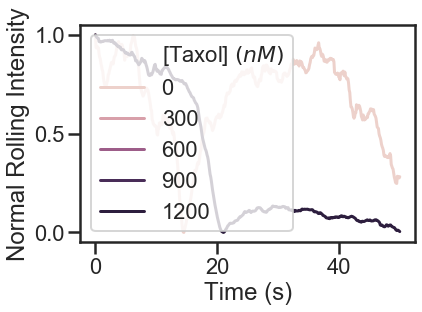

In [334]:
sns.lineplot(data=joindataGFP, x="Time (s)", y="Normal Rolling Intensity", hue=taxolnM)

In [332]:
joindataGFP = joindata[(joindata['Channel']=='GFP') & (joindata['CH']==4)]

In [333]:
joindataGFP[taxolnM].unique()

array(['1000', '100'], dtype=object)